In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
# Chargement du dataset nettoye (issu de l ETL) et import
# des librairies necessaires a l analyse exploratoire.
# On part directement de dataset_bretagne.csv : ce fichier
# contient deja toutes les variables nettoyees, normalisees
# et fusionnees pour les 2440 lignes (1233 communes 2017
# + 1207 communes 2022).
#
# FIGURES pointe vers data/processed/figures/ : toutes les
# visualisations generees dans ce notebook y seront
# sauvegardees, au meme endroit que le dataset nettoye.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW       = "../data/raw/"
PROCESSED = "../data/processed/"
FIGURES   = PROCESSED + "figures/"
os.makedirs(FIGURES, exist_ok=True)

df = pd.read_csv(
    PROCESSED + "dataset_bretagne.csv",
    dtype={'code_commune': str, 'code_dept': str, 'code_insee': str}
)

print("Dataset charge :", df.shape)
print(df.columns.tolist())

Dataset charge : (2440, 30)
['code_commune', 'nom_commune', 'code_dept', 'annee', 'nb_inscrits', 'nb_votants', 'taux_abstention', 'score_ext_gauche', 'score_gauche', 'score_centre', 'score_droite', 'score_ext_droite', 'gagnant', 'code_insee', 'population', 'superficie_km2', 'densite', 'nb_associations_pour_mille', 'taux_chomage_2016', 'taux_chomage_2021', 'pct_sans_diplome_2016', 'pct_diplome_sup_2016', 'pct_sans_diplome_2021', 'pct_diplome_sup_2021', 'revenu_median_2016', 'revenu_median_2021', 'taux_criminalite_2016', 'taux_criminalite_2021', 'nb_entreprises_pour_mille_2016', 'nb_entreprises_pour_mille_2021']


In [3]:
# ============================================================
# HARMONISATION DES INDICATEURS PAR ANNEE + DEFINITIONS PARTAGEES
# ============================================================
# Le dataset contient deux colonnes par indicateur evolutif
# (ex : taux_chomage_2016 et taux_chomage_2021). Pour l analyse
# on cree UNE colonne par indicateur, selon l annee de la ligne :
#   - annee == 2017 -> colonne _2016
#   - annee == 2022 -> colonne _2021
#
# Cette cellule definit aussi toutes les constantes reutilisees
# dans les cellules suivantes (listes de colonnes, palette de
# couleurs, labels d affichage) afin d eviter les NameError
# lies a l ordre d execution.
# ============================================================

INDICATEURS_EVOLUTIFS = [
    'taux_chomage', 'pct_sans_diplome', 'pct_diplome_sup',
    'revenu_median', 'taux_criminalite', 'nb_entreprises_pour_mille'
]

for ind in INDICATEURS_EVOLUTIFS:
    df[ind] = np.where(df['annee'] == 2017, df[f'{ind}_2016'], df[f'{ind}_2021'])

# 8 indicateurs retenus pour l analyse et le ML
INDICATEURS_COLS = [
    'taux_chomage', 'revenu_median', 'taux_criminalite',
    'population', 'nb_associations_pour_mille', 'nb_entreprises_pour_mille',
    'pct_sans_diplome', 'pct_diplome_sup'
]

# 5 scores politiques
SCORES_COLS = [
    'score_ext_gauche', 'score_gauche', 'score_centre',
    'score_droite', 'score_ext_droite'
]

GROUPES_LABELS = {
    'score_ext_gauche': 'Ext gauche',
    'score_gauche'    : 'Gauche',
    'score_centre'    : 'Centre',
    'score_droite'    : 'Droite',
    'score_ext_droite': 'Ext droite',
}

# Palette de couleurs par groupe politique (reutilisee partout)
COULEURS_GROUPES = {
    'ext_gauche' : '#762a83',
    'gauche'     : '#d6604d',
    'centre'     : '#f6e8c3',
    'droite'     : '#92c5de',
    'ext_droite' : '#1b7837',
}

print(df[INDICATEURS_COLS].describe())

       taux_chomage  revenu_median  taux_criminalite     population  \
count   2440.000000    2440.000000       2440.000000    2440.000000   
mean       9.866764   21264.379918          7.168153    2746.731148   
std        3.253192    2255.579630         11.715975    8535.578268   
min        2.312952   13420.000000          0.000000      70.000000   
25%        7.547963   19708.750000          0.000000     691.000000   
50%        9.418866   21002.500000          0.000000    1322.500000   
75%       11.721736   22570.000000         10.415131    2605.750000   
max       26.071609   32860.000000         76.827757  225081.000000   

       nb_associations_pour_mille  nb_entreprises_pour_mille  \
count                 2440.000000                2440.000000   
mean                    31.627242                  58.748015   
std                     17.404625                  25.231193   
min                      3.436426                   0.000000   
25%                     21.868099       

Geo filtre Bretagne : 1207 communes
Annee 2017 : 0 communes sans correspondance (sur 1207)
Annee 2022 : 0 communes sans correspondance (sur 1207)


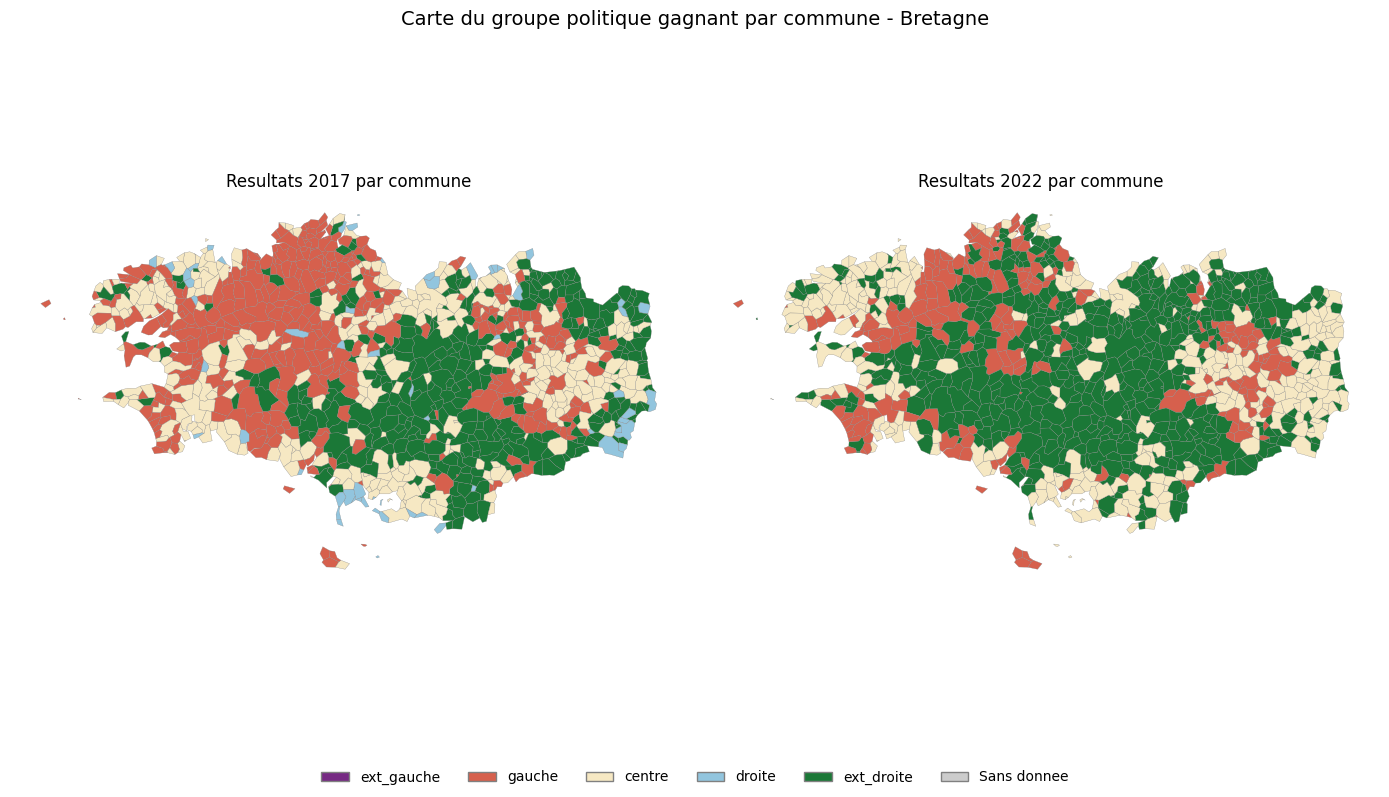

In [4]:
# ============================================================
# CARTES BRETAGNE 2017 vs 2022 - GAGNANT PAR COMMUNE
# ============================================================
# On charge le geojson des communes francaises et on le
# filtre sur les 4 departements bretons (meme logique que
# dans l ETL), car le fichier source contient les 35 094
# communes de France entiere.
#
# On fusionne ensuite ce geojson filtre avec les resultats
# electoraux (df) pour colorier chaque commune selon le
# groupe politique gagnant.
#
# Deux cartes cote a cote (2017 et 2022) permettent de
# visualiser l evolution du vote entre les deux elections.
#
# COULEUR_MANQUANTE (gris) sert de garde-fou pour les
# communes du geojson sans correspondance dans df (fusions
# de communes).
# ============================================================

import geopandas as gpd
from matplotlib.patches import Patch

DEPTS_BRETAGNE = ['22', '29', '35', '56']

geo = gpd.read_file(RAW + "communes-bretagne.geojson")
geo = geo.rename(columns={'code': 'code_insee'})
geo['code_insee'] = geo['code_insee'].astype(str).str.zfill(5)

geo['departement'] = geo['departement'].astype(str).str.zfill(2)
geo = geo[geo['departement'].isin(DEPTS_BRETAGNE)].copy()
print("Geo filtre Bretagne :", len(geo), "communes")

COULEUR_MANQUANTE = '#cccccc'

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, annee in zip(axes, [2017, 2022]):
    data_annee = df[df['annee'] == annee][['code_insee', 'gagnant']]
    geo_annee  = geo.merge(data_annee, on='code_insee', how='left')

    nb_manquants = geo_annee['gagnant'].isna().sum()
    print(f"Annee {annee} : {nb_manquants} communes sans correspondance (sur {len(geo_annee)})")

    geo_annee['couleur'] = geo_annee['gagnant'].map(COULEURS_GROUPES).fillna(COULEUR_MANQUANTE)

    geo_annee.plot(ax=ax, color=geo_annee['couleur'], edgecolor='grey', linewidth=0.2)
    ax.set_title(f"Resultats {annee} par commune")
    ax.axis('off')

legend_elements = [
    Patch(facecolor=c, edgecolor='grey', label=g)
    for g, c in COULEURS_GROUPES.items()
] + [Patch(facecolor=COULEUR_MANQUANTE, edgecolor='grey', label='Sans donnee')]

fig.legend(handles=legend_elements, loc='lower center', ncol=6, frameon=False)

plt.suptitle("Carte du groupe politique gagnant par commune - Bretagne", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIGURES + "01_carte_bretagne_2017_2022.png", dpi=150)
plt.show()

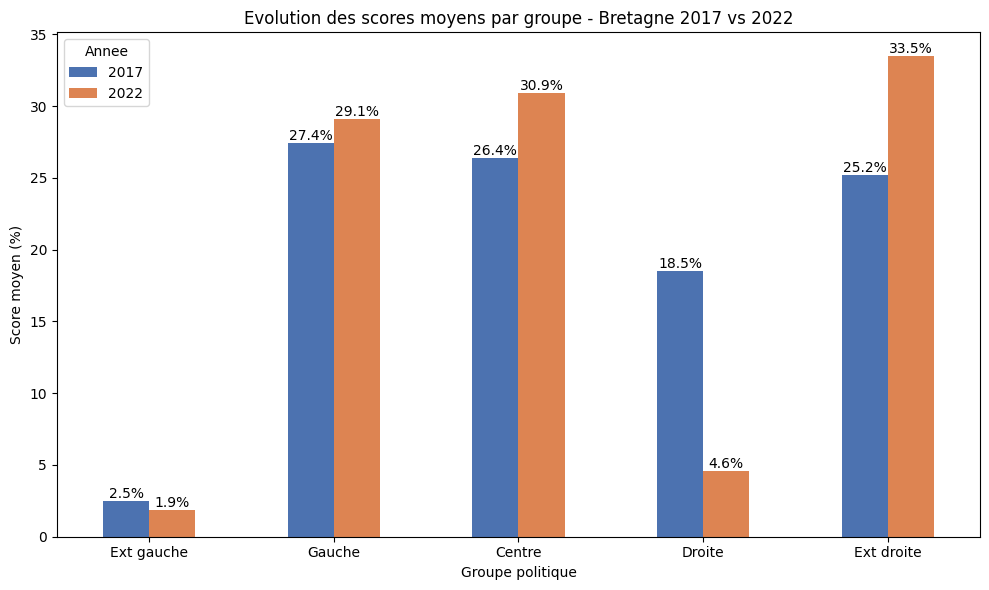

       Ext gauche     Gauche     Centre     Droite  Ext droite
annee                                                         
2017     2.455921  27.426772  26.409789  18.503633   25.204136
2022     1.894234  29.088393  30.939221   4.607606   33.470514


In [5]:
# ============================================================
# EVOLUTION DES SCORES MOYENS PAR GROUPE - 2017 vs 2022
# ============================================================
# Pour chaque groupe politique, on calcule le score moyen
# (toutes communes confondues) en 2017 et en 2022, et on les
# compare cote a cote.
#
# Objectif : montrer en un seul graphique la TENDANCE
# electorale globale en Bretagne - exactement le besoin
# metier d Electio-Analytics ("prevision des tendances
# electorales a moyen terme").
#
# bar_label() affiche la valeur au-dessus de chaque barre
# pour une lecture immediate, sans avoir besoin de lire
# l axe Y avec precision.
# ============================================================

scores_par_annee = df.groupby('annee')[SCORES_COLS].mean()
scores_par_annee = scores_par_annee.rename(columns=GROUPES_LABELS)

ax = scores_par_annee.T.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#DD8452'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title("Evolution des scores moyens par groupe - Bretagne 2017 vs 2022")
plt.ylabel("Score moyen (%)")
plt.xlabel("Groupe politique")
plt.xticks(rotation=0)
plt.legend(title='Annee')
plt.tight_layout()
plt.savefig(FIGURES + "02_evolution_scores_moyens.png", dpi=150)
plt.show()

print(scores_par_annee)

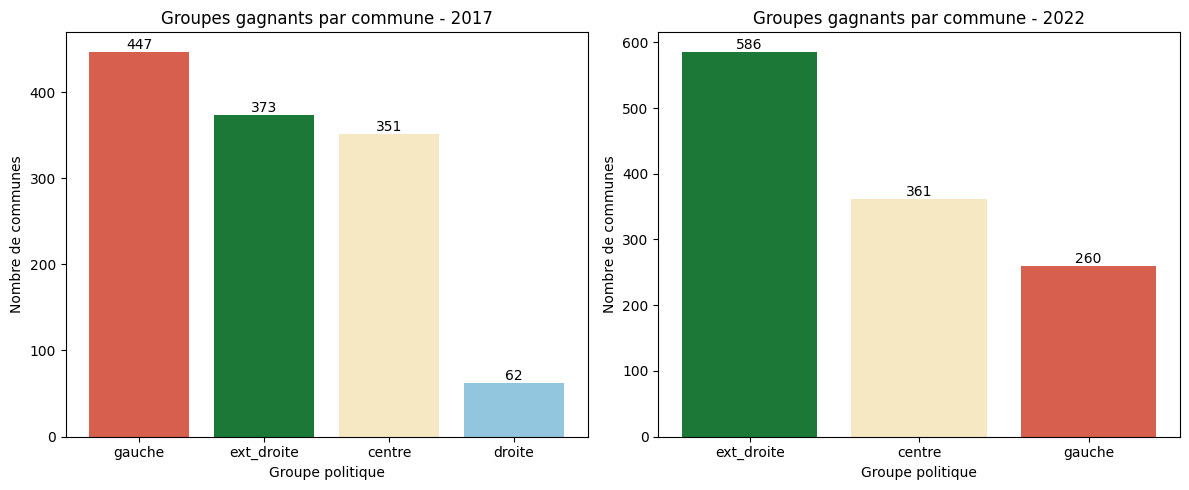

In [6]:
# ============================================================
# GROUPES GAGNANTS PAR COMMUNE - 2017 vs 2022
# ============================================================
# Pour chaque annee electorale, on compte le nombre de
# communes remportees par chaque groupe politique.
#
# Affiche cote a cote (2017 et 2022), ce graphique met en
# evidence la bascule electorale en Bretagne : en 2017 le
# groupe le plus represente est "gauche" (447 communes),
# alors qu en 2022 c est "ext_droite" qui devient largement
# majoritaire (586 communes).
#
# Complement direct du graphique precedent (scores moyens) :
# ici on raisonne en NOMBRE DE COMMUNES GAGNEES, pas en
# score moyen - les deux informations sont complementaires
# pour le jury.
#
# value_counts() ne renvoie que les groupes presents (ext_gauche
# n a jamais gagne de commune, il n apparaitra donc pas).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, annee in zip(axes, [2017, 2022]):
    counts = df[df['annee'] == annee]['gagnant'].value_counts()
    colors = [COULEURS_GROUPES[g] for g in counts.index]

    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.bar_label(bars)
    ax.set_title(f"Groupes gagnants par commune - {annee}")
    ax.set_xlabel("Groupe politique")
    ax.set_ylabel("Nombre de communes")

plt.tight_layout()
plt.savefig(FIGURES + "03_groupes_gagnants_par_annee.png", dpi=150)
plt.show()

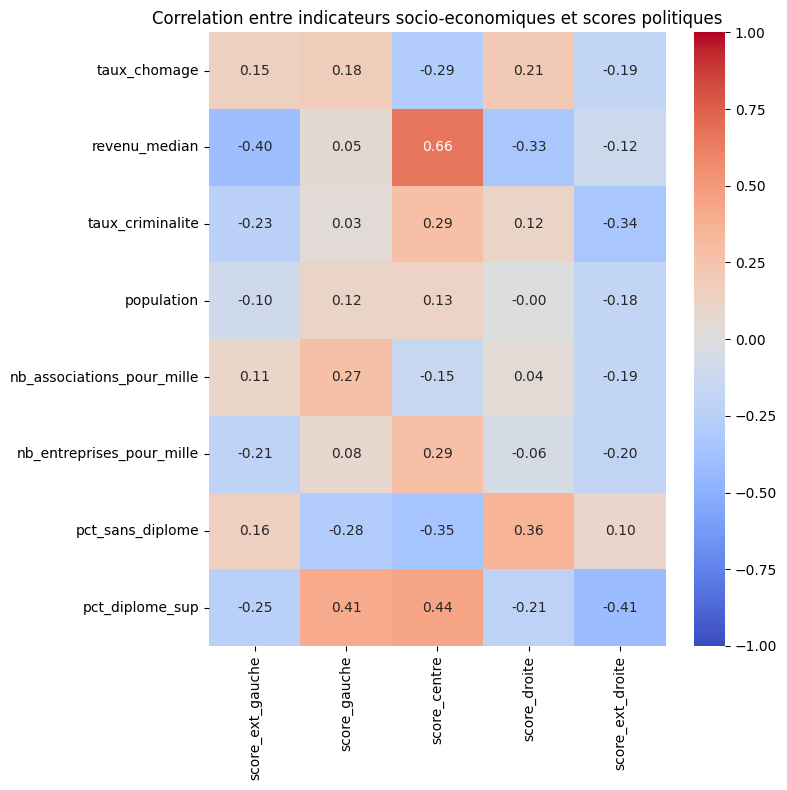

                            score_ext_gauche  score_gauche  score_centre  \
taux_chomage                        0.149515      0.175376     -0.285026   
revenu_median                      -0.402696      0.052472      0.656939   
taux_criminalite                   -0.231572      0.034097      0.287423   
population                         -0.103852      0.115286      0.128429   
nb_associations_pour_mille          0.107663      0.274368     -0.148877   
nb_entreprises_pour_mille          -0.207843      0.082438      0.285330   
pct_sans_diplome                    0.160392     -0.283086     -0.345019   
pct_diplome_sup                    -0.247233      0.406403      0.440353   

                            score_droite  score_ext_droite  
taux_chomage                    0.211993         -0.187396  
revenu_median                  -0.332271         -0.122190  
taux_criminalite                0.116762         -0.335992  
population                     -0.000948         -0.179735  
nb_associa

In [7]:
# ============================================================
# MATRICE DE CORRELATION - INDICATEURS vs SCORES POLITIQUES
# ============================================================
# Correlation de Pearson entre les 8 indicateurs et les
# 5 scores politiques (% de voix par groupe).
#
# Repond a la question du cahier des charges :
# "Parmi les donnees que vous avez selectionnees, laquelle
# est la plus correlee aux resultats des elections ?"
#
# .corr() calcule la correlation entre TOUTES les paires de
# colonnes numeriques. On extrait ensuite seulement le bloc
# indicateurs x scores avec .loc[] pour ne garder que les
# correlations pertinentes.
# ============================================================

corr_matrix = df[INDICATEURS_COLS + SCORES_COLS].corr().loc[INDICATEURS_COLS, SCORES_COLS]

plt.figure(figsize=(8, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1
)
plt.title("Correlation entre indicateurs socio-economiques et scores politiques")
plt.tight_layout()
plt.savefig(FIGURES + "04_matrice_correlation.png", dpi=150)
plt.show()

print(corr_matrix)

print(corr_matrix)

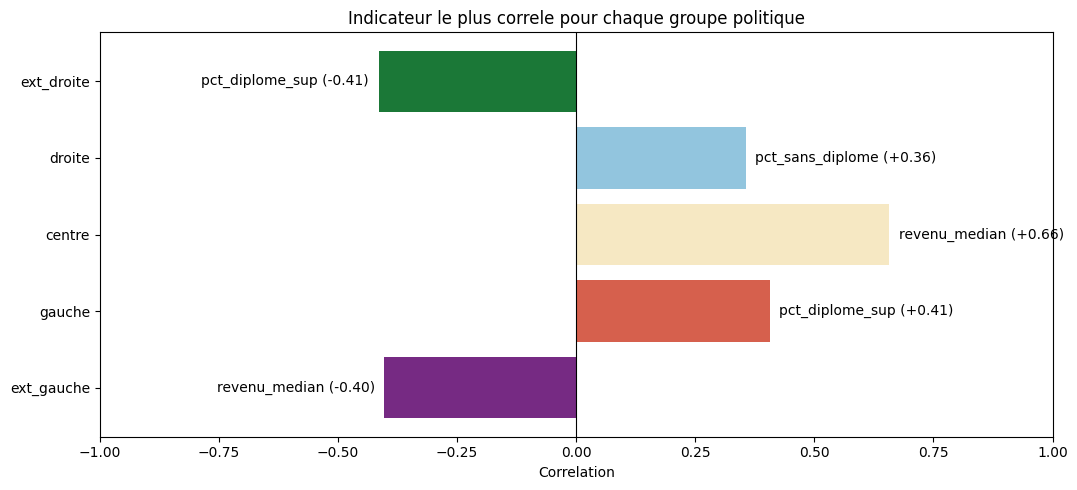

Synthese :
  ext_gauche   -> revenu_median             (r = -0.40)
  gauche       -> pct_diplome_sup           (r = +0.41)
  centre       -> revenu_median             (r = +0.66)
  droite       -> pct_sans_diplome          (r = +0.36)
  ext_droite   -> pct_diplome_sup           (r = -0.41)


In [8]:
# ============================================================
# REPONSE - INDICATEUR LE PLUS CORRELE, PAR GROUPE POLITIQUE
# ============================================================
# Pour chaque groupe politique, on identifie l indicateur qui
# lui est le plus correle (en valeur absolue), a partir de la
# matrice de correlation calculee precedemment.
#
# Cela repond a la question du CDC ("quel indicateur est le
# plus correle aux resultats electoraux ?") pour CHAQUE
# groupe, sans avoir a choisir arbitrairement un seul groupe
# "majoritaire".
#
# Chaque barre = un groupe politique. La longueur = la force
# de la correlation. Le texte affiche l indicateur concerne
# et sa valeur de correlation.
# ============================================================

resultats = {}
for score in SCORES_COLS:
    groupe = score.replace('score_', '')
    top_indicateur = corr_matrix[score].abs().idxmax()
    valeur = corr_matrix.loc[top_indicateur, score]
    resultats[groupe] = (top_indicateur, valeur)

groupes         = list(resultats.keys())
valeurs         = [v for _, v in resultats.values()]
indicateurs_top = [i for i, _ in resultats.values()]
colors          = [COULEURS_GROUPES[g] for g in groupes]

plt.figure(figsize=(11, 5))
bars = plt.barh(groupes, valeurs, color=colors)

for bar, ind, val in zip(bars, indicateurs_top, valeurs):
    decalage = 0.02 if val >= 0 else -0.02
    alignement = 'left' if val >= 0 else 'right'
    plt.text(val + decalage, bar.get_y() + bar.get_height()/2,
             f"{ind} ({val:+.2f})", va='center', ha=alignement)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-1, 1)
plt.xlabel("Correlation")
plt.title("Indicateur le plus correle pour chaque groupe politique")
plt.tight_layout()
plt.savefig(FIGURES + "05_indicateur_par_groupe.png", dpi=150)
plt.show()

print("Synthese :")
for groupe, (ind, val) in resultats.items():
    print(f"  {groupe:12s} -> {ind:25s} (r = {val:+.2f})")

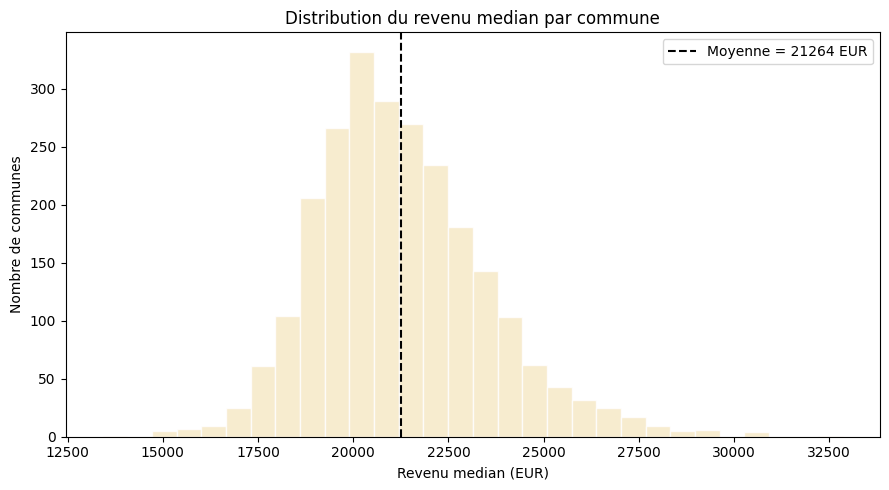

count     2440.000000
mean     21264.379918
std       2255.579630
min      13420.000000
25%      19708.750000
50%      21002.500000
75%      22570.000000
max      32860.000000
Name: revenu_median, dtype: float64


In [9]:
# ============================================================
# DISTRIBUTION DE L INDICATEUR CLE - REVENU_MEDIAN
# ============================================================
# Zoom sur l indicateur identifie comme le plus determinant
# (corr = 0.66 avec score_centre, la plus forte de toute la
# matrice). Repond a l exigence CDC "histogrammes".
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(df['revenu_median'], bins=30, color=COULEURS_GROUPES['centre'], edgecolor='white', alpha=0.8)
plt.axvline(df['revenu_median'].mean(), color='black', linestyle='--', label=f"Moyenne = {df['revenu_median'].mean():.0f} EUR")
plt.xlabel("Revenu median (EUR)")
plt.ylabel("Nombre de communes")
plt.title("Distribution du revenu median par commune")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES + "06_histogramme_revenu_median.png", dpi=150)
plt.show()

print(df['revenu_median'].describe())